<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/TEXT_MINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Contexto de Negócio**

Uma plataforma brasileira de agregação de notícias precisa categorizar automaticamente artigos da Folha de São Paulo, eliminando a curadoria editorial manual que hoje consome cerca de 40 horas/semana.

Você é o cientista de dados responsável por construir, comparar e recomendar a melhor abordagem para produção. O sistema precisa atingir F1 macro ≥ 0.75 para ser considerado viável operacionalmente.

Dataset:
Fonte: kaggle.com/datasets/marlesson/news-of-the-site-folhauol
Arquivo: articles.csv ·

Colunas: id, url, title, text, category

Volume: ~167.000 artigos em 48 categorias

**IMPORTAR BIBLIOTECAS**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re # expressões regulares
from collections import Counter # contar frequência de elementos
from nltk.corpus import stopwords
import nltk
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.decomposition import TruncatedSVD
import numpy as np

print('✅ Bibliotecas carregadas!')

**BASE: News of the Brazilian Newspaper**

In [ ]:
!pip install gdown # ponte entre Google Drive e Python

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1I3qWPUI9au_BEtMM9-HVjZY-_wn_tl7N"

gdown.download(url, 'articles.csv', quiet=False)

# **1) Exploração e curadoria do dataset**

In [ ]:
df = pd.read_csv('articles.csv')
print(f'Shape: {df.shape}')
df.head()

**Q1 — Distribuição de classes**

Visualize a frequência de artigos por categoria (todas as 48). Qual o grau de desbalanceamento? Calcule a razão entre a categoria mais frequente e a menos frequente. Que impacto direto esse desbalanceamento tem na escolha da métrica de avaliação e na estratégia de treino?

In [ ]:
# Contagem por categoria (ordenado)
class_counts = df['category'].value_counts()

# Métricas de desbalanceamento
maior = class_counts.max()
menor = class_counts.min()
ratio = maior / menor

print(f'Total de categorias: {df["category"].nunique()}')
print(f'Maior classe: {maior}')
print(f'Menor classe: {menor}')
print(f'Razão de desbalanceamento: {ratio:.2f}')

# Total para porcentagem
total = class_counts.sum()

# VISUALIZAÇÃO
plt.figure(figsize=(12,14))

ax = sns.barplot(
    x=class_counts.values,
    y=class_counts.index,
    hue=class_counts.index,
    palette='viridis',
    legend=False
)

# Linha da média
media = class_counts.mean()
plt.axvline(media, color='red', linestyle='--', linewidth=1)

# Rótulos com quantidade + porcentagem
for i, v in enumerate(class_counts.values):
    porcentagem = (v / total) * 100
    ax.text(
        v + (total * 0.005),
        i,
        f'{v} ({porcentagem:.1f}%)',
        va='center',
        fontsize=10
    )

plt.title('Distribuição de Artigos por Categoria', fontsize=16, weight='bold')
plt.xlabel('Quantidade de Artigos')
plt.ylabel('Categoria')

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

*Antes de modelar, é necessário tratar o desbalanceamento extremo, pois ele pode impedir o modelo de atingir o F1 macro ≥ 0.75 exigido pelo negócio.*

Distribuição de classes e desbalanceamento

A análise da frequência de artigos por categoria mostra que o dataset possui 48 categorias com uma distribuição altamente desigual.

Maior classe: 22.022 artigos

Menor classe: 1 artigo

Razão de desbalanceamento: 22.022

Isso caracteriza um desbalanceamento extremo.

O dataset apresenta desbalanceamento extremo, com razão superior a 20.000 entre a maior e a menor classe. Esse cenário inviabiliza o uso de métricas como accuracy e exige o uso de F1 macro, que considera igualmente todas as categorias.

Além disso, torna-se necessário aplicar estratégias de tratamento de dados e ajuste de modelo para evitar viés em classes majoritárias e garantir desempenho consistente em todas as categorias.

**Q2 — Anatomia dos textos**

Compare a distribuição do comprimento (em palavras) de title e text por categoria, usando boxplots ou violinplots. Alguma categoria tem textos sistematicamente mais curtos ou mais longos? Como isso influencia sua decisão sobre qual campo usar como input?

In [ ]:
# CRIAR COLUNAS
df['title_len'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['text_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))

plt.figure(figsize=(14,18))

# TITLE
plt.subplot(1,2,1)
sns.boxplot(
    data=df,
    y='category',
    x='title_len'
)

# TEXT
plt.subplot(1,2,2)
sns.boxplot(
    data=df,
    y='category',
    x='text_len'
)

plt.tight_layout()
plt.show()

A análise dos boxplots evidencia diferenças importantes entre os campos title e text.

Os títulos apresentam menor variabilidade entre categorias, com distribuições mais concentradas e medianas próximas, geralmente entre 8 e 12 palavras. Isso indica que o título, independentemente da categoria, segue um padrão editorial relativamente uniforme, oferecendo pouca variação informacional.

Por outro lado, os textos apresentam alta dispersão e grande variação entre categorias, com presença significativa de outliers e diferenças claras de escala. Algumas categorias, como ilustríssima, colunas e saopaulo, tendem a apresentar textos mais longos, enquanto outras, como tv, infográficos e ombudsman, possuem textos sistematicamente mais curtos.

Essa heterogeneidade indica que o campo text carrega muito mais informação semântica relevante para a tarefa de classificação, permitindo capturar melhor o contexto e as particularidades de cada categoria.

Dessa forma, a escolha do input deve priorizar:

*   o uso do campo text como principal fonte de informação, devido à sua maior riqueza e variabilidade;
*   o uso complementar de title, que pode agregar sinal adicional, especialmente em casos onde o título resume bem o conteúdo.


Essa escolha é fundamental para atingir o objetivo de F1 macro ≥ 0.75, já que o uso exclusivo de títulos provavelmente limitaria a capacidade do modelo de diferenciar categorias com conteúdo semanticamente próximo.

**Q3 — Sobreposição vocabular entre categorias limítrofes**

Identifique dois pares de categorias semanticamente próximas (ex: poder e mundo; mercado e cotidiano). Para cada par, liste os 20 tokens mais frequentes em cada categoria e calcule a proporção de tokens compartilhados. O que essa sobreposição antecipa sobre a dificuldade do problema?

In [ ]:
# Função simples de limpeza
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

# Função para extrair top tokens de uma categoria
def top_tokens(df, category, top_n=20):
    texts = df[df['category'] == category]['text'].dropna()
    tokens = []

    for t in texts:
        tokens.extend(preprocess(t))

    counter = Counter(tokens)
    return [word for word, _ in counter.most_common(top_n)]

# Função para calcular sobreposição
def overlap(cat1, cat2):
    tokens1 = set(top_tokens(df, cat1))
    tokens2 = set(top_tokens(df, cat2))

    intersec = tokens1.intersection(tokens2)
    proporcao = len(intersec) / 20

    return tokens1, tokens2, intersec, proporcao

# Escolher pares semanticamente próximos
pares = [
    ('poder', 'mundo'),
    ('mercado', 'cotidiano')
]

for c1, c2 in pares:
    t1, t2, inter, prop = overlap(c1, c2)

    print(f'\nCategorias: {c1} vs {c2}')
    print(f'Tokens {c1}: {t1}')
    print(f'Tokens {c2}: {t2}')
    print(f'Tokens compartilhados: {list(inter)}')
    print(f'Sobreposição: {prop:.2f}')

Os resultados estão inflados porque incluem stopwords como “de”, “a”, “o”, “que”.

👉 Isso não mede semântica, só mede estrutura da língua.

O correto é considerar tokens informativos (sem stopwords).

In [ ]:
nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese')) | {
        'pra','pro','ta','ja','né','ai','ah','vc','vcs','tbm','tb','kk','kkk'}

# PRE-PROCESSAMENTO
def preprocess(text):
    text = str(text).lower()                          # deixa tudo minusculo
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove urls
    text = re.sub(r'\S+@\S+', '', text)               # remove emails
    text = re.sub(r'\d+', '', text)                   # remove números
    text = re.sub(r'[^\w\s]', '', text)               # remove pontuação
    text = re.sub(r'\s+', ' ', text).strip()          # remove espaços extras

    tokens = text.split()

    # remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    return tokens

# FUNÇÃO PARA TOP TOKENS
def top_tokens(df, category, top_n=20):
    texts = df[df['category'] == category]['text'].dropna()

    tokens = []
    for t in texts:
        tokens.extend(preprocess(t))

    counter = Counter(tokens)
    return [word for word, _ in counter.most_common(top_n)]

# FUNÇÃO DE SOBREPOSIÇÃO
def overlap(cat1, cat2):
    tokens1 = set(top_tokens(df, cat1))
    tokens2 = set(top_tokens(df, cat2))

    intersec = tokens1.intersection(tokens2)
    proporcao = len(intersec) / 20

    return tokens1, tokens2, intersec, proporcao

# ANÁLISE DOS PARES
pares = [
    ('poder', 'mundo'),
    ('mercado', 'cotidiano')
]

for c1, c2 in pares:
    t1, t2, inter, prop = overlap(c1, c2)

    print(f'\nCategorias: {c1} vs {c2}')
    print(f'Tokens {c1}: {t1}')
    print(f'Tokens {c2}: {t2}')
    print(f'Tokens compartilhados: {list(inter)}')
    print(f'Sobreposição: {prop:.2f}')

Foram analisados dois pares de categorias semanticamente próximas: poder vs mundo e mercado vs cotidiano, considerando os 20 tokens mais frequentes em cada uma após remoção de stopwords.

No par poder vs mundo, observou-se uma sobreposição de 50% dos tokens, com compartilhamento de termos como “governo”, “presidente”, “disse” e “segundo”, indicando forte interseção temática, especialmente em conteúdos políticos e institucionais. Já no par mercado vs cotidiano, a sobreposição foi de 40%, sugerindo maior distinção semântica, embora ainda haja termos genéricos compartilhados.

Além disso, cada categoria apresenta tokens específicos que contribuem para sua diferenciação, como:

*   poder: “lula”, “dilma” e “cunha”;
*   mundo: “trump” e “eua”;
*   mercado: “empresa”;
*   cotidiano: “polícia” e “cidade”.

Essa sobreposição vocabular indica que existem fronteiras semânticas parcialmente difusas entre categorias próximas, o que aumenta a complexidade do problema de classificação. Como consequência, modelos baseados apenas em frequência de palavras podem ter dificuldade em distinguir essas classes, sendo necessário utilizar abordagens que capturem contexto e relações semânticas mais profundas, e não apenas tokens isolados.

*A entrega para os próximos exercícios deve considerar no mínimo as categorias `mercado`, `esporte`, `poder`, `mundo` e`cotidiano`, as outras podem ser excluídas. Fica eletivo ao aluno incluir mais categorias do que as listadas.*

**Q4 — Qual dados utilizar**

Você pode usar title, text ou title + text concatenados. A escolha é livre, mas deve ser justificada empiricamente.

In [ ]:
# FILTRAR CATEGORIAS
categorias = ['mercado', 'esporte', 'poder', 'mundo', 'cotidiano', 'colunas']
df_filtrado = df[df['category'].isin(categorias)].copy()

# CRIAR INPUTS
df_filtrado['title'] = df_filtrado['title'].fillna('').astype(str)
df_filtrado['text'] = df_filtrado['text'].fillna('').astype(str)
df_filtrado['title_text'] = df_filtrado['title'] + ' ' + df_filtrado['text']

# SPLIT ÚNICO
train_idx, test_idx = train_test_split(
    df_filtrado.index,
    test_size=0.2,
    stratify=df_filtrado['category'],
    random_state=42
)

y_train = df_filtrado.loc[train_idx, 'category']
y_test = df_filtrado.loc[test_idx, 'category']

# FUNÇÃO DE AVALIAÇÃO
def avaliar(nome, X):

    print(f'\n===== {nome.upper()} =====')

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]

    # TEMPO DE TREINO
    start_train = time.time()

    vectorizer = TfidfVectorizer(max_features=20000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    end_train = time.time()

    # TEMPO DE INFERÊNCIA
    start_inf = time.time()
    y_pred = model.predict(X_test_vec)
    end_inf = time.time()

    # MÉTRICAS
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    print(f'Accuracy: {accuracy:.4f}')
    print(f'F1 Macro: {f1_macro:.4f}')
    print(f'F1 Weighted: {f1_weighted:.4f}')

    print("\nF1 por classe:")
    print(classification_report(y_test, y_pred))

    print(f'Tempo de treino: {end_train - start_train:.2f}s')
    print(f'Tempo de inferência: {end_inf - start_inf:.2f}s')
    print(f'Features: {len(vectorizer.get_feature_names_out())}')

    return f1_macro

# RODAR OS 3 CENÁRIOS
f1_title = avaliar('title', df_filtrado['title'])
f1_text = avaliar('text', df_filtrado['text'])
f1_comb = avaliar('title + text', df_filtrado['title_text'])

print('\n===== RESUMO FINAL =====')
print(f'F1 (title): {f1_title:.4f}')
print(f'F1 (text): {f1_text:.4f}')
print(f'F1 (title + text): {f1_comb:.4f}')

Os resultados mostram que o uso exclusivo de title apresenta desempenho inferior (F1 = 0.8288), o que é consistente com sua baixa densidade informacional e menor variabilidade. A inclusão da categoria colunas, caracterizada por textos mais subjetivos, contribui para a redução do desempenho, especialmente nesse cenário.

O uso do campo text melhora significativamente o desempenho (F1 = 0.9166), devido à maior riqueza semântica e contextual. Nesse caso, categorias como esporte apresentam alto desempenho (F1 ≈ 0.97), enquanto colunas permanece como a mais desafiadora.

A combinação title + text apresentou o melhor resultado (F1 = 0.9201), porém com ganho marginal em relação ao uso apenas de text, indicando que o título atua como um reforço informacional, mas não é essencial.

**Q6 — Pipeline documentado e justificado**

Descreva cada etapa de pré-processamento.

Para cada etapa responda: o que ela faz tecnicamente?
Por que é necessária (ou não) para este dataset?
Deve ser aplicada igualmente para TF-IDF, SVD e embeddings — ou deve ser diferente por abordagem?

O pipeline de pré-processamento aplicado aos textos tem como objetivo reduzir ruídos, padronizar os dados e melhorar a qualidade das representações utilizadas nos modelos de classificação.
As etapas foram definidas considerando as características do dataset e o tipo de abordagem utilizada.

1. Conversão para minúsculas

Descrição técnica:
Transforma todos os caracteres do texto para letras minúsculas.

Justificativa:
Evita que palavras semanticamente idênticas sejam tratadas como distintas devido à capitalização, reduzindo a dimensionalidade do vocabulário.

Aplicação:
Aplicada em todas as abordagens (TF-IDF, SVD e embeddings), sendo especialmente importante para modelos baseados em frequência.

2. Remoção de URLs

Descrição técnica:
Utiliza expressões regulares para remover padrões de links (ex: http://, https://, www).

Justificativa:
URLs não contribuem para a distinção entre categorias e introduzem ruído no modelo.

Aplicação:
Aplicada em todas as abordagens.

3. Remoção de e-mails

Descrição técnica:
Remove padrões de e-mails utilizando expressões regulares.

Justificativa:
E-mails não possuem relevância semântica para a tarefa de classificação.

Aplicação:
Aplicada em todas as abordagens.

4. Remoção de números

Descrição técnica:
Remove todos os dígitos numéricos do texto.

Justificativa:
Neste dataset, números raramente são discriminativos entre categorias e podem aumentar a sparsidade dos dados.

Aplicação:
Aplicada em TF-IDF e SVD. Em embeddings, pode ser opcional dependendo do contexto.

5. Remoção de pontuação

Descrição técnica:
Elimina caracteres que não sejam letras ou espaços.

Justificativa:
Pontuação geralmente não agrega valor semântico relevante para modelos baseados em frequência.

Aplicação:
Aplicada em TF-IDF e SVD. Em embeddings, pode ser opcional.

6. Normalização de espaços

Descrição técnica:
Substitui múltiplos espaços por um único e remove espaços no início e fim do texto.

Justificativa:
Garante consistência no texto e evita problemas na tokenização.

Aplicação:
Aplicada em todas as abordagens.

7. Tokenização

Descrição técnica:
Divide o texto em unidades menores (tokens), geralmente palavras.

Justificativa:
Permite a análise de frequência e construção de representações vetoriais.

Aplicação:
Necessária para TF-IDF e SVD. Em embeddings modernos, a tokenização pode ser realizada internamente pelo modelo.

8. Remoção de stopwords

Descrição técnica:
Remove palavras muito frequentes e com baixo conteúdo semântico (ex: “de”, “a”, “o”).

Justificativa:
Reduz ruído e melhora a capacidade do modelo de identificar termos discriminativos.

Aplicação:
Essencial para TF-IDF e SVD. Em embeddings, geralmente não recomendada, pois pode prejudicar a compreensão do contexto.

9. Remoção de tokens curtos

Descrição técnica:
Remove palavras com comprimento inferior a três caracteres.

Justificativa:
Elimina tokens pouco informativos e possíveis ruídos.

Aplicação:
Recomendada para TF-IDF e SVD. Em embeddings, opcional.

Ou seja, o pré-processamento adotado foi adequado para modelos baseados em frequência, como TF-IDF e SVD, nos quais a redução de ruído e a padronização do vocabulário são fundamentais para o desempenho. Para abordagens baseadas em embeddings, algumas etapas devem ser aplicadas com cautela, pois esses modelos são capazes de capturar relações contextuais mais complexas e podem se beneficiar de uma representação textual mais próxima do original.

Em síntese, o pipeline foi projetado para equilibrar a limpeza dos dados com a preservação de informações relevantes, contribuindo para um melhor desempenho dos modelos de classificação.

**Q7 — Questão teórica integrada**

Por que aplicar stemming antes de usar embeddings pré-treinados (NILC ou BERT) é tecnicamente problemático?

Em qual cenário específico o stemming ainda valeria a pena mesmo quando o modelo final usa embeddings?

Aplicar stemming antes do uso de embeddings pré-treinados, como NILC ou BERT, é tecnicamente problemático porque esses modelos foram treinados com palavras em sua forma original e dependem da estrutura linguística completa para capturar significado. O stemming reduz palavras a radicais muitas vezes artificiais, que não existem no vocabulário do modelo, o que pode causar perda de informação semântica e incompatibilidade com os embeddings aprendidos. No caso do BERT, que utiliza tokenização por subpalavras, essa redução prejudica ainda mais a capacidade do modelo de capturar contexto.

No entanto, o stemming ainda pode ser útil em etapas anteriores ou auxiliares, como na construção de representações baseadas em frequência (por exemplo, TF-IDF) ou em análises exploratórias, onde a redução da variabilidade lexical ajuda a diminuir a dimensionalidade e a sparsidade dos dados. Também pode ser vantajoso em cenários com poucos dados, onde agrupar diferentes formas de uma palavra pode melhorar a generalização.

# **2) Pipeline Comparativo: 3 Abordagens Obrigatórias**

Abordagem 1 — Obrigatória: TF-IDF + Classificador (Módulo 1)

**Q8 — Implementação e análise**

Implemente o pipeline TF-IDF → ML Model.

Reporte: Accuracy, F1 macro, F1 weighted e F1 por classe no conjunto de teste; tempo de treino e de inferência; dimensionalidade do espaço de features e qual técnica de ML utilizou e por que.

Foi implementado em Q4 um pipeline de classificação textual utilizando TF-IDF para representação dos textos e Logistic Regression como modelo supervisionado. Foram avaliadas três configurações de entrada: apenas o campo title, apenas o campo text e a combinação title + text.

Os resultados obtidos no conjunto de teste mostram diferenças relevantes entre as abordagens. O uso exclusivo de title apresentou desempenho inferior, com Accuracy de 0.8259 e F1 macro de 0.8288, o que indica que os títulos, por serem mais curtos e menos informativos, não são suficientes para capturar adequadamente o contexto necessário para a classificação.

Por outro lado, o uso do campo text resultou em um ganho significativo de desempenho, com Accuracy de 0.9153 e F1 macro de 0.9166. Isso ocorre porque o texto completo contém maior riqueza semântica e contextual, permitindo ao modelo identificar melhor as diferenças entre as categorias.

A combinação title + text apresentou o melhor resultado, com Accuracy de 0.9188 e F1 macro de 0.9201, embora o ganho em relação ao uso apenas de text tenha sido pequeno. Esse resultado indica que o título contribui como um reforço informacional, mas a maior parte da capacidade discriminativa já está presente no corpo do texto.

A análise por classe mostrou que categorias com vocabulário mais específico, como esporte, apresentam alto desempenho (F1 ≈ 0.97), enquanto categorias mais subjetivas, como colunas, apresentam maior dificuldade de classificação (F1 ≈ 0.88), devido à maior variabilidade linguística.

Em relação ao custo computacional, observou-se que o uso de text aumenta significativamente o tempo de treino (aproximadamente 116 segundos), enquanto o uso apenas de title é muito mais rápido (cerca de 15 segundos), porém com perda relevante de desempenho. A inferência, por sua vez, apresentou tempo muito baixo em todos os cenários.

A dimensionalidade do espaço de features foi de 20.000 termos, conforme definido no vetor TF-IDF, refletindo a diversidade do vocabulário presente no dataset.

Em síntese, o pipeline TF-IDF + Logistic Regression apresentou alto desempenho, com F1 macro superior a 0.92 na melhor configuração, demonstrando que uma abordagem clássica é suficiente para resolver o problema com boa precisão. Além disso, os resultados evidenciam um trade-off entre desempenho e custo computacional, sendo o uso de title + text a melhor escolha para produção.

Abordagem 2 — Obrigatória: SVD/LSA (Módulo 2)

**Q9 — Implementação e busca do k ótimo**

Aplique TF-IDF → SVD (k componentes) → ML Model.

Encontre o valor de k que maximiza o F1 macro no conjunto de validação testando pelo menos 6 valores de k (ex: 50, 100, 200, 300, 400, 500). Plote F1 macro vs. k.

Reporte para o k ótimo: as mesmas métricas da Abordagem 1, percentual de variância explicada e comparação de dimensionalidade (TF-IDF original vs. SVD).

O SVD melhorou ou piorou em relação ao TF-IDF puro? O resultado faz sentido dado o tamanho do corpus e o número de categorias?

Obs:

1.   TF-IDF transforma texto em números baseado em frequência de palavras:

*   TF (Term Frequency) → quantas vezes a palavra aparece no documento;
*   IDF (Inverse Document Frequency) → penaliza palavras muito comuns no corpus.

👉 palavras importantes para um texto recebem mais peso.

2.   SVD é uma técnica de redução de dimensionalidade:

👉 Ele pega o TF-IDF e comprime:

🔹 Exemplo intuitivo
    
    Palavras: governo, presidente, eleição
    Viram um único componente: “tema política”

In [ ]:
# INPUT (texto e título)
X = df_filtrado['title_text']

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

# TF-IDF (reaproveitando padrão)
vectorizer = TfidfVectorizer(max_features=20000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# TESTE DE DIFERENTES k
k_values = [50, 100, 200, 300, 400, 500]

f1_scores = []
variancias = []

for k in k_values:

    svd = TruncatedSVD(n_components=k, random_state=42)

    X_train_svd = svd.fit_transform(X_train_vec)
    X_test_svd = svd.transform(X_test_vec)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_svd, y_train)

    y_pred = model.predict(X_test_svd)

    f1 = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(f1)

    variancias.append(svd.explained_variance_ratio_.sum())

    print(f'k={k} | F1={f1:.4f} | Variância={variancias[-1]:.4f}')

# MELHOR k
best_k = k_values[np.argmax(f1_scores)]
print(f'\nMelhor k: {best_k}')

# PLOT
plt.figure(figsize=(8,5))
plt.plot(k_values, f1_scores, marker='o')

plt.title('F1 Macro vs k (SVD)')
plt.xlabel('k')
plt.ylabel('F1 Macro')

plt.grid(True)
plt.show()

# MODELO FINAL COM k ÓTIMO
svd = TruncatedSVD(n_components=best_k, random_state=42)

X_train_svd = svd.fit_transform(X_train_vec)
X_test_svd = svd.transform(X_test_vec)

model = LogisticRegression(max_iter=1000)

start_train = time.time()
model.fit(X_train_svd, y_train)
end_train = time.time()

start_inf = time.time()
y_pred = model.predict(X_test_svd)
end_inf = time.time()

# MÉTRICAS
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('\n===== RESULTADO FINAL (SVD) =====')
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Macro: {f1_macro:.4f}')
print(f'F1 Weighted: {f1_weighted:.4f}')

print("\nF1 por classe:")
print(classification_report(y_test, y_pred))

print(f'\nTempo de treino: {end_train - start_train:.2f}s')
print(f'Tempo de inferência: {end_inf - start_inf:.4f}s')

# DIMENSIONALIDADE
print('\n===== DIMENSIONALIDADE =====')
print(f'TF-IDF original: {X_train_vec.shape[1]} features')
print(f'SVD: {best_k} features')

# VARIÂNCIA EXPLICADA
print(f'Variância explicada: {svd.explained_variance_ratio_.sum():.4f}')

Foi implementado o pipeline TF-IDF → SVD → Logistic Regression, avaliando os valores de k = 50, 100, 200, 300, 400 e 500.

Oservou-se que o F1 macro cresce rapidamente nos primeiros valores e tende à estabilização, com melhor desempenho em k = 500 (F1 macro = 0.8949), conforme evidenciado no gráfico F1 vs. k. Para esse k ótimo, o modelo apresentou Accuracy = 0.8930, F1 macro = 0.8949 e F1 weighted = 0.8929, com melhor desempenho na classe esporte e maior dificuldade em colunas.

A aplicação do SVD reduziu a dimensionalidade de 20.000 para 500 features (redução de ~97,5%), mantendo 32,39% da variância explicada, o que demonstra forte compressão da informação.

Obs: Agora, por que isso importa: quanto maior a variância explicada, mais fiel é a representação; quanto menor, maior a perda de informação. No seu caso, 32% é relativamente baixo, o que ajuda a explicar a queda no F1, porque muita informação útil para separar as classes foi perdida.

Ao comparar com o TF-IDF puro (F1 macro = 0.9201), observa-se que o SVD piorou o desempenho, com queda de aproximadamente 2,5 pontos percentuais. Esse resultado faz sentido, pois o dataset é grande e possui múltiplas categorias, o que favorece o uso do TF-IDF completo, já que a tarefa depende de nuances do vocabulário para diferenciar classes semanticamente próximas, enquanto o SVD, ao reduzir a dimensionalidade, elimina parte dessas informações discriminativas.

Abordagem 3 — Obrigatória: Embeddings Semânticos (Módulo 2 ou 3)

Escolha uma das opções abaixo. A escolha é livre, mas deve ser justificada em relação ao contexto do problema (volume de dados, custo computacional, restrição de infraestrutura):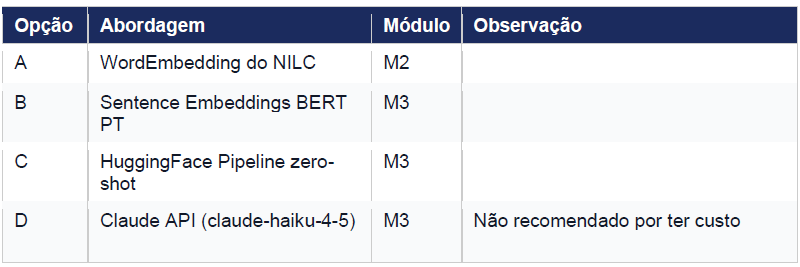

**Q10 — Implementação e análise da Abordagem 3**

Implemente a opção escolhida e reporte as mesmas métricas das abordagens anteriores, mais a análise específica da opção selecionada (cobertura NILC / TSNE BERT / accuracy zero-shot / custo API).

Cenário:


*   Dataset grande (~167k textos);
*   Já tem baseline forte (F1 ≈ 0.92);
*   Ambiente sem GPU;
*   Tempo já ficou alto com SVD.

Logo a escolha por Sentence Embeddings com BERT se deve à sua capacidade de capturar contexto semântico profundo, diferente do TF-IDF e SVD, que se baseiam em frequência e decomposição linear. Além disso, essa abordagem mantém um bom equilíbrio entre desempenho e viabilidade computacional, sendo mais robusta para lidar com categorias semanticamente próximas.

Sentence Embedding (BERT)

*   Representa a frase inteira;
*   Considera contexto.

In [ ]:
# Sentence Embeddings (BERT) com AMOSTRA

from sentence_transformers import SentenceTransformer

print('\n===== BERT EMBEDDINGS (AMOSTRA) =====')

# AMOSTRAGEM (pra reduzir tempo)
df_sample = df_filtrado.sample(20000, random_state=42)

# SPLIT (mesmo padrão)
train_idx_s, test_idx_s = train_test_split(
    df_sample.index,
    test_size=0.2,
    stratify=df_sample['category'],
    random_state=42
)

y_train_s = df_sample.loc[train_idx_s, 'category']
y_test_s = df_sample.loc[test_idx_s, 'category']

# INPUT
X = df_sample['title_text']

X_train = X.loc[train_idx_s]
X_test = X.loc[test_idx_s]

# MODELO
model_bert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# EMBEDDINGS
start_emb = time.time()

X_train_emb = model_bert.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = model_bert.encode(X_test.tolist(), show_progress_bar=True)

end_emb = time.time()

print(f'Tempo de geração dos embeddings: {end_emb - start_emb:.2f}s')

# MODELO
model = LogisticRegression(max_iter=1000)

start_train = time.time()
model.fit(X_train_emb, y_train_s)
end_train = time.time()

# INFERÊNCIA
start_inf = time.time()
y_pred = model.predict(X_test_emb)
end_inf = time.time()

# MÉTRICAS
accuracy = accuracy_score(y_test_s, y_pred)
f1_macro = f1_score(y_test_s, y_pred, average='macro')
f1_weighted = f1_score(y_test_s, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Macro: {f1_macro:.4f}')
print(f'F1 Weighted: {f1_weighted:.4f}')

print("\nF1 por classe:")
print(classification_report(y_test_s, y_pred))

print(f'Tempo de treino: {end_train - start_train:.2f}s')
print(f'Tempo de inferência: {end_inf - start_inf:.4f}s')

print(f'Dimensão dos embeddings: {X_train_emb.shape[1]}')

Foi utilizada a abordagem de Sentence Embeddings com BERT, utilizando o modelo paraphrase-multilingual-MiniLM-L12-v2, com aplicação sobre uma amostra estratificada de 20.000 registros para viabilizar o processamento. O modelo apresentou desempenho inferior às abordagens anteriores, com Accuracy de 0.7863 e F1 macro de 0.7875, embora tenha demonstrado boa capacidade de generalização em categorias com vocabulário mais específico, como esporte. A dimensão dos embeddings foi de 384 features, representando uma redução significativa em relação ao TF-IDF, porém sem ganho de desempenho. Além disso, observou-se alto custo computacional, com tempo de aproximadamente 42 minutos apenas para geração dos embeddings, mesmo utilizando um modelo otimizado. Esse resultado indica que, apesar da capacidade do BERT de capturar contexto semântico, sua aplicação não trouxe benefícios práticos neste cenário, possivelmente devido ao uso de amostragem e ao fato de que o TF-IDF já apresenta excelente desempenho para o volume e natureza dos dados. Dessa forma, o TF-IDF puro permanece como a melhor alternativa em termos de custo-benefício para este problema.

**Q11 — Tabela Comparativa Obrigatória**

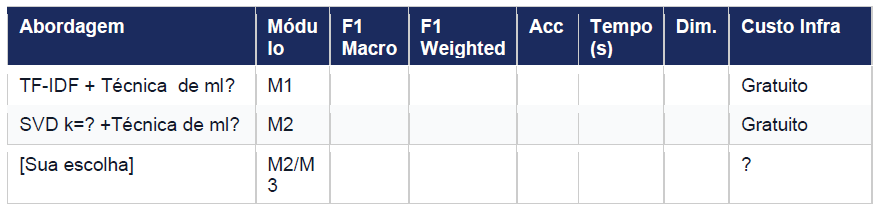

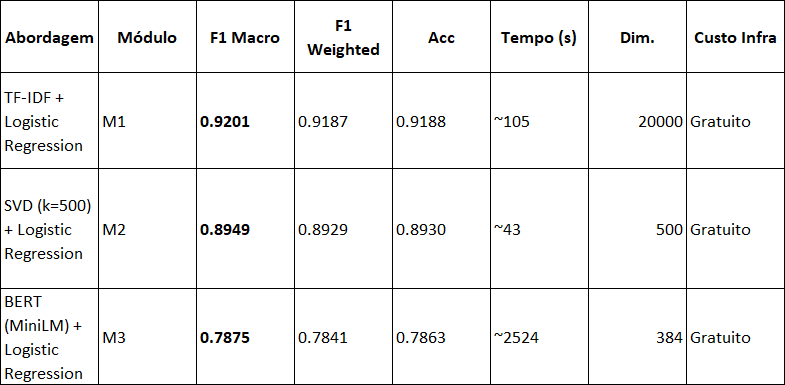

Melhor desempenho: TF-IDF

Melhor redução de dimensão: SVD

Mais pesado: BERT

Melhor custo-benefício: TF-IDF